In [ ]:
%load_ext autoreload
%autoreload 2
# automatically pick up changes made in src file

# LEDGAR DATASET NLP: text preprocessing and modelling

Starts from the cleaned `train` saved at the end of `eda.ipynb`.

**Flow of this notebook**
1. Imports
2. Load the EDA output
3. Text preprocessing: clean → lemmatise → save
4. Stop words
5. TF-IDF
6. Model: multiclass softmax logistic regression
7. Error analysis (validation set)

## 1. Imports
All src files are imported here, once.

In [2]:
from pathlib import Path
import sys; sys.path.append('..')     # lets the notebook find the src folder

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from src.clean import clean_text # cleaning function
from src.lemmetizer import Lemmatizer # spaCy lemmatiser class
from src.tf_idf import tfid # builds the TF-IDF vectoriser
from src.multi_class_lr_softmax import MultiClassLogisticRegression # model class
from src.classification_error_analysis import ErrorAnalysis # error analysis class

## 2. Load the EDA output
- `train`: de-duplicated, lowercased, with `word_count` (saved by `eda.ipynb`)
- validation and test were not changed in the EDA, so they are read from `data/raw` in the cleaning step

In [3]:
train = pd.read_parquet("../data/interim/train_eda.parquet")
print("loaded train:", train.shape)   # expect (59933, 5)
train.head()

loaded train: (59933, 4)


,text,label,label_name,word_count
0,except as otherwise set forth in this debentur...,97,Waivers,47
1,no erisa event has occurred or is reasonably e...,39,Erisa,74
2,this amendment may be executed by one or more ...,26,Counterparts,53
3,"from time to time, as and when required by the...",45,Further Assurances,146
4,"commencing march 7, 2016 and during the employ...",11,Base Salary,211


## 3. Text preprocessing
Bag of words, TF-IDF, Word2Vec all need CLEAN text first.
- text preprocessing: lowercasing, remove special characters, tokenising, stop words, lemmatisation
- Bag of words - turning text into word counts - TF-IDF works on this foundation
- Word2Vec / sentence embeddings - used downstream

**Steps**
1. Read a sample of raw clauses. Note every odd pattern: numbers, money, (ii), punctuation and so on.
2. Cleaning function with `re` (called from `src/clean.py`, so it is reproducible). Takes one clause and returns a cleaner version:
    - lowercase
    - money becomes moneytoken
    - numbers become numtoken
    - remove bracketed list markers like (a) and (ii)
    - remove remaining punctuation and symbols
    - collapse extra spaces
3. Lemmatise with spaCy. Feed it the cleaned clauses, and get back each clause with words in base form. spaCy tokenises internally to do this.
4. Save it. Add the result as a column and save to `data/processed`, so the slow lemmatising only runs once.
5. Find legal stop words (section 4).
6. TF-IDF: give TfidfVectorizer the lemmatised column and the stop-word list. It tokenises, removes stop words and builds the numbers (section 5).

### 3a. Look at raw clauses

In [4]:
train.text
# different types of termanology to consider when cleaning: dates written in long format, money, numbers, section refrences, numbering in lists, addresses, phone numbers, emails, urls

0        except as otherwise set forth in this debentur...
1        no erisa event has occurred or is reasonably e...
2        this amendment may be executed by one or more ...
3        from time to time, as and when required by the...
4        commencing march 7, 2016 and during the employ...
                               ...                        
59928    any notice required to be delivered to the com...
59929    this agreement may be terminated by any purcha...
59930    by signing this agreement, you agree to keep b...
59931    the loan documents cannot be amended, terminat...
59932    for purposes of determining lenders' obligatio...
Name: text, Length: 59933, dtype: str

### 3b. Clean
Test the cleaning function on one example first, then apply it to train, validation and test.

In [5]:
# test the cleaning function first:
testing_text = 'Notices: (a) send to legal@acme.com within 30 days; (ii) pay $1,250,000.00 per Section 5.2 of the Agreement.'
result = clean_text(testing_text)
print(result)

notices send to emailtoken within numtoken days pay moneytoken per section numtoken of the agreement


In [6]:
# clean all files: train, validation , test
splits = {
    "train": train,
    "validation": pd.read_parquet("../data/raw/validation.parquet"),
    "test": pd.read_parquet("../data/raw/test.parquet"),
}

for name, df in splits.items():
    df["clean_text"] = df["text"].apply(clean_text)
    print(name, df.shape)

train (59933, 5)
validation (10000, 4)
test (10000, 4)


### 3c. Tokenise and lemmatise (spaCy)
- spaCy's small English model is a chain of steps: tokenizer → tagger → attribute_ruler → lemmatizer → parser → ner
- lemmatising does not need parser and ner, so they are turned off (much faster)
- the `Lemmatizer` class (`src/lemmetizer.py`) loads spaCy ONCE; the model lives in `lem.nlp`
- one-time install, in the terminal (not here): `python -m spacy download en_core_web_sm`

In [7]:
lem = Lemmatizer()   # loads spaCy once

# test the lemmatiser on the cleaned example (it tokenises too)
doc = lem.nlp(result)
print([token.lemma_ for token in doc])

['notice', 'send', 'to', 'emailtoken', 'within', 'numtoken', 'day', 'pay', 'moneytoken', 'per', 'section', 'numtoken', 'of', 'the', 'agreement']


In [8]:
processed = Path("../data/processed")
processed.mkdir(parents=True, exist_ok=True)

for name, df in splits.items(): # .items (loop over dictinoary) gives both the key and value, i.e. name and df
    df = lem.lemmatize_clauses(df) # tokenise + lemmatise -> new column: lemmatized_text
    df.to_parquet(processed / f"proc_{name}.parquet", index=False) # save
    print(name, df.shape)

train (59933, 6)
validation (10000, 5)
test (10000, 5)


### 3d. Sanity check after preprocessing
- cleaning removes apostrophes
- the lemmatiser can then mangle lone letters: won't → won t → win
- so check how many informal contractions are in the text column

In [9]:
train[train.text.str.contains("'t")] #  no rows therefore no contractions have been used, all meaning remain the same in setnences of contractions, e.g. "don't" = "do not", "can't" = "cannot", "won't" = "will not"

,text,label,label_name,word_count,clean_text,lemmatized_text


## 4. Stop words
Start from scikit-learn's English stop-word list, then decide which words to keep and which legal words to add.

In [10]:
# extract english stop words to find out which need to be made exempt from the list:
print(f"English stop words: {len(ENGLISH_STOP_WORDS)}")
sorted_stop_words = sorted(list(ENGLISH_STOP_WORDS))

# Write each word to a new line in a text file
with open('sklearn_english_stop_words.txt', 'w', encoding='utf-8') as file:
    for word in sorted_stop_words:
        file.write(f"{word}\n")

English stop words: 318


- Check stop words - if they turn up mostly in specific clause types, they help separate classes = keep
- Words such as amount, due, full, against, first and per were left in the stop-word list. They are only moderately concentrated in some classes; keeping them can be tested later on validation

In [11]:
# share of clauses containing each word, and which clause types they appear in
# \b = whole word only (otherwise "per" also matches perform, period, property)
for word in ("amongst", "per", "full", "against", "without", "within", "between", "among", "first", "except", "otherwise", "bill"):
    has_word = train.text.str.contains(rf"\b{word}\b")
    print(f"Clauses containing '{word}': {has_word.mean()*100:.2f}%")
    print(train[has_word]['label_name'].value_counts(normalize=True).round(2).head(5) * 100, "\n")

Clauses containing 'amongst': 0.01%
label_name
Expenses       25.0
Consents       25.0
Assignments    25.0
Solvency       25.0
Name: proportion, dtype: float64 

Clauses containing 'per': 1.78%
label_name
Base Salary       24.0
Interests         14.0
Vacations         12.0
Capitalization    10.0
Fees               5.0
Name: proportion, dtype: float64 

Clauses containing 'full': 7.46%
label_name
Severability         12.0
Survival              8.0
Insurances            5.0
Entire Agreements     5.0
Terminations          4.0
Name: proportion, dtype: float64 

Clauses containing 'against': 9.78%
label_name
Litigations         14.0
Indemnifications    11.0
Insurances           7.0
Governing Laws       4.0
Taxes                4.0
Name: proportion, dtype: float64 

Clauses containing 'without': 19.43%
label_name
Governing Laws     17.0
Assignments         6.0
Severability        4.0
Amendments          3.0
Confidentiality     3.0
Name: proportion, dtype: float64 

Clauses containing 'within

Words exempt from the stop-word list - removing them would change the meaning of clauses, and so the classification:
- **Negations** (they flip meaning): no · not · nor · never · neither · none · nothing · nobody · without · cannot
- **Clause-name words**: further (from Further Assurances) · interest (from Interests)

In [12]:
stop_words_set = set(ENGLISH_STOP_WORDS)

# KEEP in text (remove them from the stop-word list)
exempt_words = {'no', 'not', 'nor', 'never', 'neither', 'none', 'nothing',
                'nobody', 'without', 'cannot', 'further', 'interest'}

# Common legal words to REMOVE from the text (add them to the stop-word list)
legal_words = {'shall', 'party', 'agreement', 'hereof', 'hereunder', 'herein'}

# Final list: built-in + legal words - exemptions
stop_words_set = (stop_words_set | legal_words) - exempt_words

print(type(stop_words_set), len(stop_words_set))   # must stay a set of WORDS - don't convert to str

<class 'set'> 311


## 5. TF-IDF
- Validation and test play the role of future data the model has never seen. Their whole job is to tell you how the model will do in real life.
- train: `fit_transform` (learn the vocabulary + IDF, then convert)
- validation and test: `transform` ONLY (no leakage)

In [13]:
# read in the lemmatised files:
proc_train = pd.read_parquet(processed / "proc_train.parquet")
proc_val = pd.read_parquet(processed / "proc_validation.parquet")
proc_test = pd.read_parquet(processed / "proc_test.parquet")
proc_train.columns

Index(['text', 'label', 'label_name', 'word_count', 'clean_text',
       'lemmatized_text'],
      dtype='str')

In [15]:
vectorizer = tfid(list(stop_words_set))

# fit and transform the train dataset:
x_train = vectorizer.fit_transform(proc_train.lemmatized_text)

# transform the learned vectorizer on validation and test - no leakage
x_val = vectorizer.transform(proc_val.lemmatized_text)
x_test = vectorizer.transform(proc_test.lemmatized_text)

feature_names = vectorizer.get_feature_names_out()   # the column (word) names
print("x_train:", x_train.shape, "| non-zeros:", x_train.nnz)

x_train: (59933, 95559) | non-zeros: 4347226


### Observe the sparse matrix

In [16]:
i = 0                                   # row number of the clause to look at
row = x_train[i]
words = feature_names[row.indices]      # the columns this clause actually uses
scores = row.data                       # their TF-IDF scores

print(proc_train["lemmatized_text"].iloc[i])
print(pd.Series(scores, index=words).sort_values(ascending=False).head(15))
pd.DataFrame(x_train[:5, :10].toarray(), columns=feature_names[:10])

except as otherwise set forth in this debenture the company for itself and its legal representative successor and assign expressly waive presentment protest demand notice of dishonor notice of nonpayment notice of maturity notice of protest presentment for the purpose of accelerate maturity and diligence in collection
presentment             0.246179
protest                 0.241237
maturity                0.219186
debenture company       0.216035
diligence collection    0.216035
maturity notice         0.212773
protest demand          0.209947
nonpayment notice       0.203209
accelerate maturity     0.193997
notice nonpayment       0.188541
dishonor notice         0.185006
presentment protest     0.181284
assign expressly        0.180612
company legal           0.178120
waive presentment       0.173874
dtype: float64


,aa,aaa,aaa accordance,aaa administrative,aaa arbitration,aaa arbitrator,aaa commercial,aaa designate,aaa dispute,aaa effect
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The TF-IDF matrix has ~95,000 features, but each clause uses only about 73 of them on average; the matrix is over 99.9% empty, so it is stored as a sparse matrix.

(Update the numbers after rerunning with the stop-word fix.)

## 6. Model: multiclass softmax logistic regression
- y = the label column of each split: y_train, y_val, y_test
- `label_names`: lookup from label number to clause name, e.g. 47 → "Governing Laws"

In [17]:
y_train = proc_train.label
y_val = proc_val.label
y_test = proc_test.label

# pairs each number with its name, then makes a lookup dictionary
# zip lines up the two columns side by side
label_names = dict(zip(proc_train["label"], proc_train["label_name"]))

Call the model from the src file.
- `train()`: learn the weights
- `evaluate_train()`: score on train - compare with validation to check for overfitting
- `validate()`: score on validation - unseen data, used to choose settings
- `eval_test()`: final exam - run ONCE at the very end

In [18]:
lr = MultiClassLogisticRegression(x_train, x_val, x_test,
                                  y_train, y_val, y_test,
                                  C=1.0, class_weight='balanced')

lr.train() # learn weights
train_preds, train_scores = lr.evaluate_train() # the model guesses train labels, and they're marked
val_preds, val_scores = lr.validate()           # the model guesses validation labels, and they're marked

Settings: C=1.0, class_weight=balanced
Training multiclass softmax logistic regression...
Number of classes: 100
train      accuracy 0.8985 | macro F1 0.8865 | micro F1 0.8985
validation accuracy 0.8393 | macro F1 0.7797 | micro F1 0.8393


Results:
- train: 
- validation: 
- gap (train − validation): 

## 7. Error analysis (validation set)
Uses `src/error_analysis.py` → `ErrorAnalysis` class. Validation shows authentic weaknesses on unseen data.
1. Per-class scores, worst F1 first: which clause types are weak?
2. TP / FP / FN / TN per clause type
3. Top confused pairs: which types get mixed up with which?
4. One weak class in detail: where did its clauses go?
5. Read the actual wrong clauses
6. Confusion matrix picture (overview)
7. Group the mistakes into 3-4 reasons and count them (e.g. overlapping labels / too rare / long or merged clauses)

In [19]:
ea = ErrorAnalysis(y_true=y_val, y_pred=val_preds,
                   label_names=label_names,
                   classes=lr.model.classes_,       # fixed order: same 100 classes in every table
                   texts=proc_val["text"])           # original clause text, to read mistakes

In [20]:
# 1. per-class scores - worst F1 first (check the support column: are the worst ones small classes?)
ea.report_df().head(15)

,precision,recall,f1-score,support
Books,0.000000,0.000000,0.000000,0
Assigns,0.100000,0.333333,0.153846,3
Applicable Laws,0.254902,0.376812,0.304094,69
Jurisdictions,0.342857,0.363636,0.352941,33
Venues,0.237288,0.736842,0.358974,19
General,0.556604,0.393333,0.460938,150
Qualifications,0.600000,0.375000,0.461538,8
Powers,0.444444,0.533333,0.484848,15
Enforcements,0.578947,0.478261,0.523810,46
Modifications,0.446154,0.725000,0.552381,40


In [21]:
# 2. TP / FP / FN / TN per clause type - sort by FN = types the model misses most
ea.counts().sort_values("FN", ascending=False).head(15)

,TP,FP,FN,TN
Governing Laws,367,39,127,9467
General,59,47,91,9803
Payments,120,38,55,9787
Amendments,203,26,54,9717
Taxes,166,17,48,9769
Terms,124,12,45,9819
Applicable Laws,26,76,43,9855
Waivers,115,26,40,9819
Authorizations,66,24,40,9870
Terminations,156,29,37,9778


In [22]:
# 3. top confused pairs: one row per (true, predicted) pair, most common first
ea.top_confusions(n=15)

,true,predicted,count
0,Governing Laws,Applicable Laws,73
1,Applicable Laws,Governing Laws,33
2,Amendments,Modifications,25
3,Governing Laws,Venues,24
4,Authorizations,Authority,21
5,Survival,Warranties,19
6,Tax Withholdings,Withholdings,18
7,Indemnifications,Indemnity,18
8,Definitions,Defined Terms,16
9,Taxes,Withholdings,16


In [23]:
# 4. one weak class in detail - change the name to any class from step 1
ea.class_confusions("Assigns", n=5)

Binding Effects         1
Assigns                 1
Successors              1
Adjustments             0
Anti-Corruption Laws    0
dtype: int64

In [24]:
# 5. read the actual mistakes
mistakes = ea.mistakes()
print(len(mistakes), "wrong out of", len(y_val))
mistakes.head(20)

1607 wrong out of 10000


,text,true,predicted
1,This Agreement embodies the entire agreement b...,Amendments,Entire Agreements
2,The substantive laws of the State of Texas wil...,Governing Laws,Venues
4,This Amendment shall be interpreted and constr...,Governing Laws,Applicable Laws
14,No failure on the part of any Party to exercis...,Waivers,No Waivers
16,In the event of any of (i) Participant’s retir...,Disability,Vesting
20,"The rights, powers and remedies of Lender unde...",Waivers,No Waivers
24,This Agreement shall be governed by and constr...,Applicable Laws,Governing Laws
31,The Plan shall be construed and administered i...,Applicable Laws,Governing Laws
35,The Company shall promptly reimburse Kelley Dr...,Fees,Expenses
43,State of New York. Counsel to the Bridge Admin...,Governing Laws,Titles


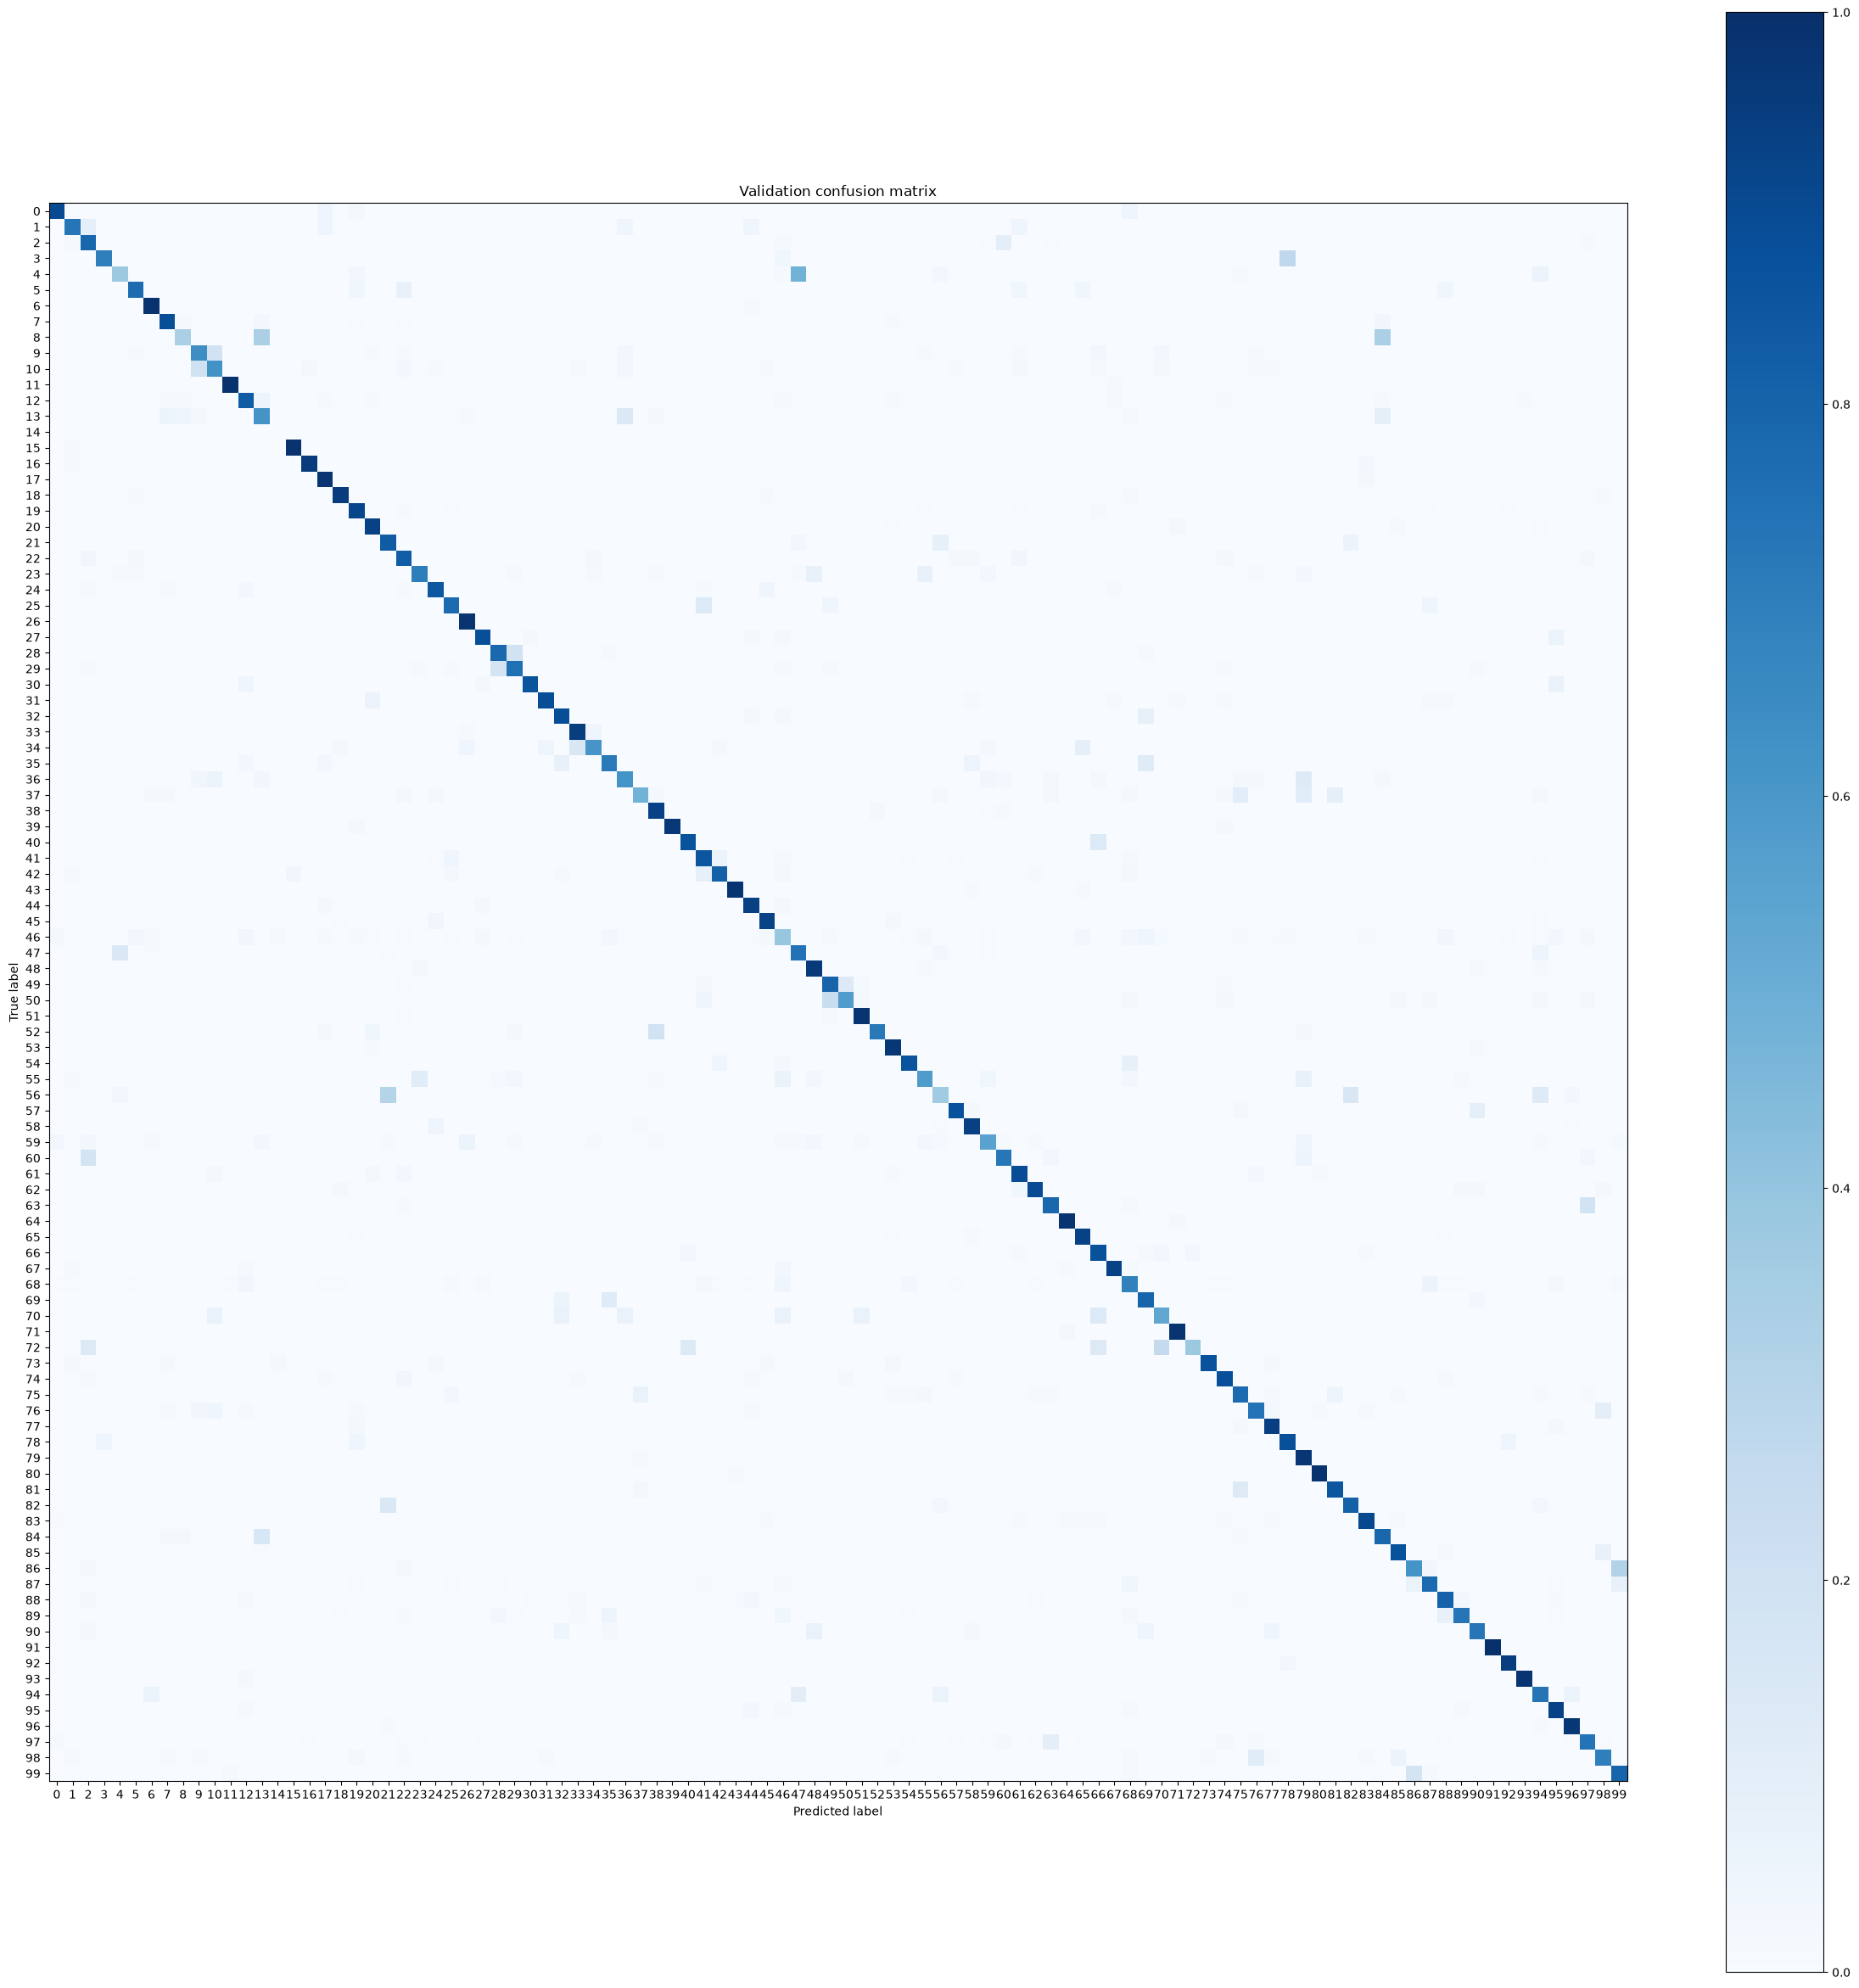

In [25]:
# 6. confusion matrix picture (quick overview only - use step 3 for the details)
ea.plot_confusion_matrix(size=30)

Error analysis findings:
- 
- 